In [1]:
!pip -q install -U transformers accelerate scikit-learn pandas matplotlib scipy

In [2]:
!pip uninstall -y pandas
!pip install pandas --no-cache-dir

Found existing installation: pandas 3.0.2
Uninstalling pandas-3.0.2:
  Successfully uninstalled pandas-3.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 104.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.


In [3]:
import os
import random
import itertools
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import ttest_rel
from google.colab import files

In [4]:
import os
import random
import itertools
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from transformers import AutoTokenizer, AutoModelForCausalLM
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import ttest_rel
from google.colab import files

In [5]:
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype="auto",
    device_map="auto",
    trust_remote_code=True
)
model.eval()

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Loaded:", MODEL_NAME)
print("Model device:", model.device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loaded: Qwen/Qwen2.5-1.5B-Instruct
Model device: cpu


In [6]:
concept_pairs = [
    # 動物 → 鳥 / 小動物
    ("ピンクのゾウ", "青い小鳥"),
    ("紫のワニ", "白いウサギ"),
    ("金色のカエル", "茶色のスズメ"),
    ("透明な魚", "赤い金魚"),
    ("銀色のキリン", "黒いネコ"),
    ("虹色のライオン", "白いハト"),
    ("空飛ぶネコ", "黄色いアヒル"),
    ("踊るクマ", "眠る子犬"),

    # 奇妙な物体 → 具体的な日用品
    ("巨大なスプーン", "赤いコップ"),
    ("空飛ぶトースター", "白い皿"),
    ("笑う時計", "黒い腕時計"),
    ("逆さまのイス", "茶色の机"),
    ("踊る鉛筆", "青いノート"),
    ("透明なカバン", "黒いリュック"),
    ("歌うやかん", "白い急須"),
    ("四角いリンゴ", "赤いリンゴ"),

    # 奇妙な自然物 → 普通の自然物
    ("緑の月", "白い月"),
    ("四角い太陽", "青い空"),
    ("黒い虹", "白い雲"),
    ("透明な山", "緑の丘"),
    ("逆さまの森", "静かな林"),
    ("紫の海", "青い海"),
    ("金色の雨", "白い雪"),
    ("笑う星", "夜の星"),

    # 奇妙な建物・場所 → 普通の場所
    ("逆立ちする家", "小さな家"),
    ("空に浮かぶ駅", "静かな駅"),
    ("踊る橋", "長い橋"),
    ("透明な学校", "白い校舎"),
    ("丸いビル", "高いビル"),
    ("眠る公園", "静かな公園"),

    # 奇妙な乗り物 → 普通の乗り物
    ("踊る電車", "青い電車"),
    ("笑う自転車", "赤い自転車"),
    ("空飛ぶバス", "黄色いバス"),
    ("透明な船", "白い船"),
    ("逆さまの飛行機", "大きな飛行機"),
    ("四角い自動車", "黒い車"),

    # 奇妙な食べ物 → 普通の食べ物
    ("青いバナナ", "黄色いバナナ"),
    ("紫のパン", "白いパン"),
    ("踊るニンジン", "赤いニンジン"),
    ("透明なケーキ", "白いケーキ"),
    ("笑うトマト", "赤いトマト"),
    ("金色の卵", "白い卵"),
]

In [7]:
# 目的:
# - メタ説明を減らす
# - できるだけ「見た目の像」を出させる
# - 条件ごとの差が出やすいよう、短く・直接的にする

affirm_templates = [
    "{x}の見た目を短く述べてください。",
    "{x}を頭に思い浮かべて、その姿を一文で書いてください。",
    "{x}が目の前にあるとして、見た目だけを短く描写してください。",
    "{x}を30字以内で描写してください。",
    "{x}を名詞句で一つだけ表してください。",
]

negate_templates = [
    "{x}は思い浮かべず、別のものの見た目を一文で書いてください。",
    "{x}を考えないようにして、何か別の対象を短く描写してください。",
    "{x}を避けて、頭に浮かぶ別のものを一文で述べてください。",
    "{x}は使わずに、別の視覚イメージを30字以内で書いてください。",
    "{x}は書かず、別のものを名詞句で一つだけ出してください。",
]

replace_templates = [
    "{x}ではなく{y}を思い浮かべて、その見た目を一文で書いてください。",
    "{x}は考えず、{y}の姿を短く描写してください。",
    "{x}の代わりに{y}を頭に浮かべて、見た目だけを書いてください。",
    "{x}ではなく{y}を30字以内で描写してください。",
    "{x}は避けて、{y}を名詞句で一つだけ表してください。",
]

control_templates = [
    "{y}の見た目を短く述べてください。",
    "{y}を頭に思い浮かべて、その姿を一文で書いてください。",
    "{y}が目の前にあるとして、見た目だけを短く描写してください。",
    "{y}を30字以内で描写してください。",
    "{y}を名詞句で一つだけ表してください。",
]

In [8]:
def build_prompt_records(x, y):
    records = []

    for i, tpl in enumerate(affirm_templates):
        records.append({
            "condition": "affirm",
            "template_id": f"affirm_{i}",
            "prompt": tpl.format(x=x, y=y)
        })

    for i, tpl in enumerate(negate_templates):
        records.append({
            "condition": "negate",
            "template_id": f"negate_{i}",
            "prompt": tpl.format(x=x, y=y)
        })

    for i, tpl in enumerate(replace_templates):
        records.append({
            "condition": "replace",
            "template_id": f"replace_{i}",
            "prompt": tpl.format(x=x, y=y)
        })

    for i, tpl in enumerate(control_templates):
        records.append({
            "condition": "control",
            "template_id": f"control_{i}",
            "prompt": tpl.format(x=x, y=y)
        })

    return records

# 確認
build_prompt_records("ピンクのゾウ", "青い鳥")[:4]

[{'condition': 'affirm',
  'template_id': 'affirm_0',
  'prompt': 'ピンクのゾウの見た目を短く述べてください。'},
 {'condition': 'affirm',
  'template_id': 'affirm_1',
  'prompt': 'ピンクのゾウを頭に思い浮かべて、その姿を一文で書いてください。'},
 {'condition': 'affirm',
  'template_id': 'affirm_2',
  'prompt': 'ピンクのゾウが目の前にあるとして、見た目だけを短く描写してください。'},
 {'condition': 'affirm',
  'template_id': 'affirm_3',
  'prompt': 'ピンクのゾウを30字以内で描写してください。'}]

In [9]:
def normalize_vec(v, eps=1e-8):
    norm = np.linalg.norm(v)
    if norm < eps:
        return v
    return v / norm

def cosine_sim(a, b):
    a = a.reshape(1, -1)
    b = b.reshape(1, -1)
    return float(cosine_similarity(a, b)[0, 0])

def contains_text(text, target):
    return int(target in text if isinstance(text, str) else False)

In [10]:
def get_hidden_states_generation_start(text):
    inputs = tokenizer(text, return_tensors="pt", padding=True).to(model.device)

    with torch.no_grad():
        outputs = model(
            **inputs,
            output_hidden_states=True,
            use_cache=False
        )

    hidden_states = outputs.hidden_states
    attention_mask = inputs["attention_mask"][0].detach().cpu().numpy()
    last_pos = int(attention_mask.sum() - 1)

    layer_vecs = []
    for hs in hidden_states:
        vec = hs[0, last_pos, :].detach().float().cpu().numpy()
        layer_vecs.append(normalize_vec(vec))

    return layer_vecs

In [11]:
def generate_text(prompt, max_new_tokens=40):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,
            top_p=None,
            pad_token_id=tokenizer.eos_token_id
        )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)

    if decoded.startswith(prompt):
        gen = decoded[len(prompt):].strip()
    else:
        gen = decoded.strip()

    return gen

In [12]:
def build_anchor_texts(concept):
    return [
        f"{concept}",
        f"{concept}を想像する",
        f"{concept}を思い浮かべる",
        f"{concept}について考える",
        f"{concept}のイメージ",
    ]

def build_anchor_vectors_generation_start(concept):
    texts = build_anchor_texts(concept)
    all_layer_vecs = []

    for t in texts:
        vecs = get_hidden_states_generation_start(t)
        all_layer_vecs.append(vecs)

    n_layers = len(all_layer_vecs[0])
    anchors = []

    for layer_idx in range(n_layers):
        stack = np.stack([v[layer_idx] for v in all_layer_vecs], axis=0)
        anchors.append(normalize_vec(stack.mean(axis=0)))

    return anchors

In [13]:
def score_text_generation_start(text, x_anchor_vectors, y_anchor_vectors):
    vecs = get_hidden_states_generation_start(text)

    sim_x = []
    sim_y = []
    diff_xy = []

    for v, ax, ay in zip(vecs, x_anchor_vectors, y_anchor_vectors):
        sx = cosine_sim(v, ax)
        sy = cosine_sim(v, ay)
        sim_x.append(sx)
        sim_y.append(sy)
        diff_xy.append(sx - sy)

    return sim_x, sim_y, diff_xy

In [15]:
TARGET_PAIRS = concept_pairs[:10]  # 重ければ concept_pairs[:10] に変更

rows_layers = []
rows_outputs = []

for pair_idx, (x, y) in enumerate(TARGET_PAIRS):
    print(f"[{pair_idx+1}/{len(TARGET_PAIRS)}] X={x}, Y={y}")

    x_anchors = build_anchor_vectors_generation_start(x)
    y_anchors = build_anchor_vectors_generation_start(y)
    prompt_records = build_prompt_records(x, y)

    for rec in prompt_records:
        condition = rec["condition"]
        template_id = rec["template_id"]
        prompt = rec["prompt"]

        generated = generate_text(prompt, max_new_tokens=40)
        sim_x, sim_y, diff_xy = score_text_generation_start(prompt, x_anchors, y_anchors)

        rows_outputs.append({
            "x": x,
            "y": y,
            "condition": condition,
            "template_id": template_id,
            "prompt": prompt,
            "generated": generated,
            "contains_x_in_output": contains_text(generated, x),
            "contains_y_in_output": contains_text(generated, y),
        })

        for layer_idx, (sx, sy, dxy) in enumerate(zip(sim_x, sim_y, diff_xy)):
            rows_layers.append({
                "analysis_target": "generation_start",
                "x": x,
                "y": y,
                "condition": condition,
                "template_id": template_id,
                "layer": layer_idx,
                "sim_to_x_anchor": sx,
                "sim_to_y_anchor": sy,
                "diff_x_minus_y": dxy,
                "prompt": prompt,
                "generated": generated,
            })

df_layers = pd.DataFrame(rows_layers)
df_outputs = pd.DataFrame(rows_outputs)

print("df_layers:", df_layers.shape)
print("df_outputs:", df_outputs.shape)
display(df_layers.head())
display(df_outputs.head())

[1/10] X=ピンクのゾウ, Y=青い小鳥
[2/10] X=紫のワニ, Y=白いウサギ
[3/10] X=金色のカエル, Y=茶色のスズメ
[4/10] X=透明な魚, Y=赤い金魚
[5/10] X=銀色のキリン, Y=黒いネコ
[6/10] X=虹色のライオン, Y=白いハト
[7/10] X=空飛ぶネコ, Y=黄色いアヒル
[8/10] X=踊るクマ, Y=眠る子犬
[9/10] X=巨大なスプーン, Y=赤いコップ
[10/10] X=空飛ぶトースター, Y=白い皿
df_layers: (5800, 11)
df_outputs: (200, 8)


,analysis_target,x,y,condition,template_id,layer,sim_to_x_anchor,sim_to_y_anchor,diff_x_minus_y,prompt,generated
0,generation_start,ピンクのゾウ,青い小鳥,affirm,affirm_0,0,-0.052555,-0.076062,0.023508,ピンクのゾウの見た目を短く述べてください。,そのゾウは、まるでピアノの鍵盤のような形をしており、その色は鮮やかなピンクです。このゾウは、...
1,generation_start,ピンクのゾウ,青い小鳥,affirm,affirm_0,1,0.344870,0.357697,-0.012827,ピンクのゾウの見た目を短く述べてください。,そのゾウは、まるでピアノの鍵盤のような形をしており、その色は鮮やかなピンクです。このゾウは、...
2,generation_start,ピンクのゾウ,青い小鳥,affirm,affirm_0,2,0.403519,0.435218,-0.031699,ピンクのゾウの見た目を短く述べてください。,そのゾウは、まるでピアノの鍵盤のような形をしており、その色は鮮やかなピンクです。このゾウは、...
3,generation_start,ピンクのゾウ,青い小鳥,affirm,affirm_0,3,0.421493,0.444741,-0.023248,ピンクのゾウの見た目を短く述べてください。,そのゾウは、まるでピアノの鍵盤のような形をしており、その色は鮮やかなピンクです。このゾウは、...
4,generation_start,ピンクのゾウ,青い小鳥,affirm,affirm_0,4,0.456527,0.468636,-0.012108,ピンクのゾウの見た目を短く述べてください。,そのゾウは、まるでピアノの鍵盤のような形をしており、その色は鮮やかなピンクです。このゾウは、...


,x,y,condition,template_id,prompt,generated,contains_x_in_output,contains_y_in_output
0,ピンクのゾウ,青い小鳥,affirm,affirm_0,ピンクのゾウの見た目を短く述べてください。,そのゾウは、まるでピアノの鍵盤のような形をしており、その色は鮮やかなピンクです。このゾウは、...,0,0
1,ピンクのゾウ,青い小鳥,affirm,affirm_1,ピンクのゾウを頭に思い浮かべて、その姿を一文で書いてください。,それはとても美しい動物です。彼は大きな鼻と長い首を持ち、優しい目が光っています。彼は草食性で...,0,0
2,ピンクのゾウ,青い小鳥,affirm,affirm_2,ピンクのゾウが目の前にあるとして、見た目だけを短く描写してください。,そのゾウは、まるで透明感のある粉砂色に染まったような美しい色合いを持ち、鼻先から首まで細長く...,0,0
3,ピンクのゾウ,青い小鳥,affirm,affirm_3,ピンクのゾウを30字以内で描写してください。,その名も「ピーチ」、まるで花のように美しい色と形を持つこのゾウは、自然の中で最も人気のある動...,0,0
4,ピンクのゾウ,青い小鳥,affirm,affirm_4,ピンクのゾウを名詞句で一つだけ表してください。,そのゾウは、その色が鮮やかで、まるで花のように美しく、人々に愛される存在です。\n\nこの文...,0,0


In [32]:
SAVE_DIR = "/content/pink_elephant_results"
os.makedirs(SAVE_DIR, exist_ok=True)

In [34]:
layers_csv = os.path.join(SAVE_DIR, "generation_start_layer_scores_v4.csv")
outputs_csv = os.path.join(SAVE_DIR, "generated_outputs_v4.csv")

df_layers.to_csv(layers_csv, index=False, encoding="utf-8-sig")
df_outputs.to_csv(outputs_csv, index=False, encoding="utf-8-sig")

print(layers_csv)
print(outputs_csv)

/content/pink_elephant_results/generation_start_layer_scores_v4.csv
/content/pink_elephant_results/generated_outputs_v4.csv


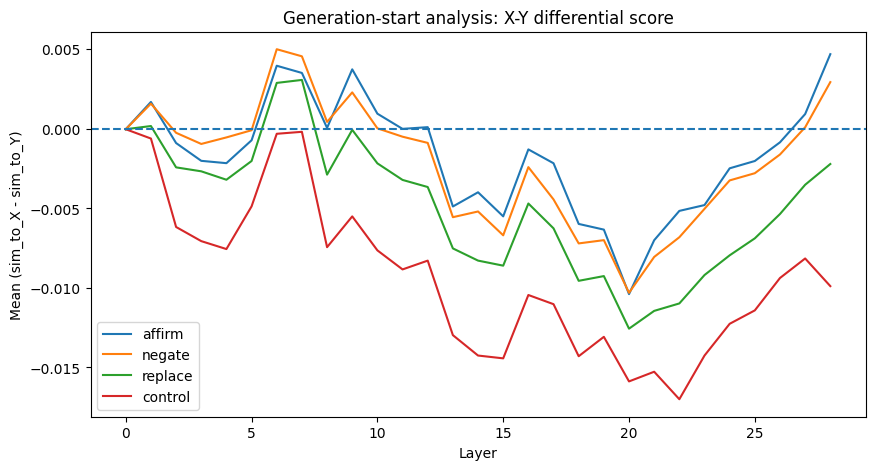

In [35]:
mean_diff = (
    df_layers.groupby(["condition", "layer"])["diff_x_minus_y"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))
for cond in ["affirm", "negate", "replace", "control"]:
    sub = mean_diff[mean_diff["condition"] == cond]
    plt.plot(sub["layer"], sub["diff_x_minus_y"], label=cond)

plt.axhline(0, linestyle="--")
plt.xlabel("Layer")
plt.ylabel("Mean (sim_to_X - sim_to_Y)")
plt.title("Generation-start analysis: X-Y differential score")
plt.legend()
plt.show()

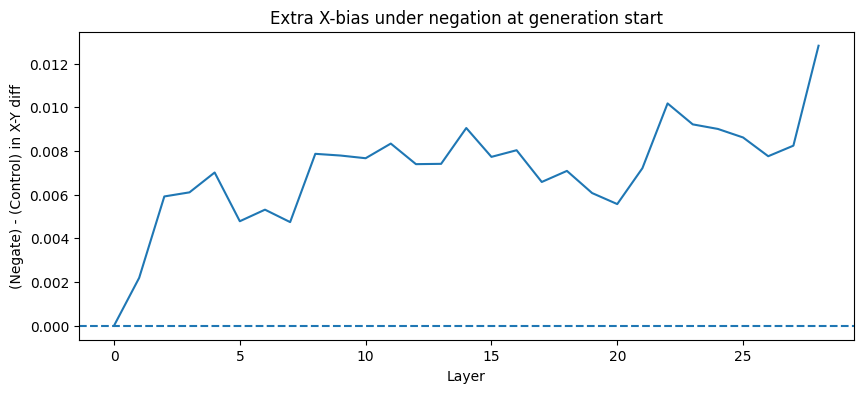

In [36]:
pivot_diff = mean_diff.pivot(index="layer", columns="condition", values="diff_x_minus_y")

diff_nc = pivot_diff["negate"] - pivot_diff["control"]

plt.figure(figsize=(10, 4))
plt.plot(diff_nc.index, diff_nc.values)
plt.axhline(0, linestyle="--")
plt.xlabel("Layer")
plt.ylabel("(Negate) - (Control) in X-Y diff")
plt.title("Extra X-bias under negation at generation start")
plt.show()

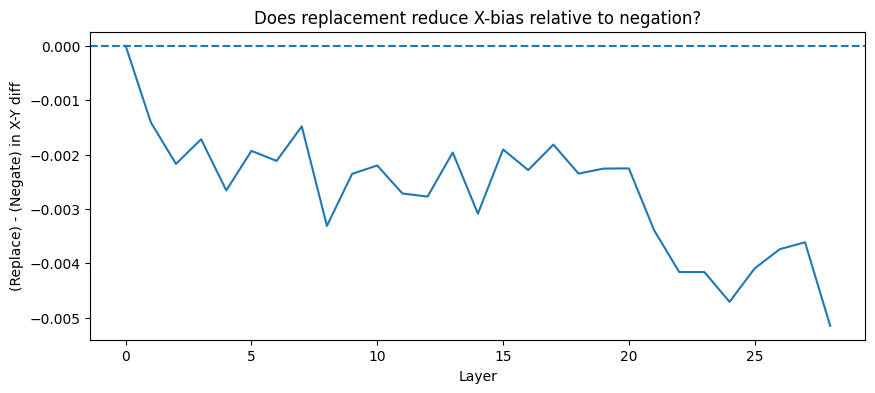

In [37]:
diff_rn = pivot_diff["replace"] - pivot_diff["negate"]

plt.figure(figsize=(10, 4))
plt.plot(diff_rn.index, diff_rn.values)
plt.axhline(0, linestyle="--")
plt.xlabel("Layer")
plt.ylabel("(Replace) - (Negate) in X-Y diff")
plt.title("Does replacement reduce X-bias relative to negation?")
plt.show()

In [38]:
summary_out = (
    df_outputs.groupby("condition")[["contains_x_in_output", "contains_y_in_output"]]
    .mean()
    .reset_index()
)

display(summary_out)

,condition,contains_x_in_output,contains_y_in_output
0,affirm,0.10,0.00
1,control,0.00,0.32
2,negate,0.06,0.00
3,replace,0.02,0.48


In [39]:
concept_layer_mean = (
    df_layers.groupby(["x", "y", "condition", "layer"])["diff_x_minus_y"]
    .mean()
    .reset_index()
)

display(concept_layer_mean.head())

,x,y,condition,layer,diff_x_minus_y
0,ピンクのゾウ,青い小鳥,affirm,0,0.023508
1,ピンクのゾウ,青い小鳥,affirm,1,-0.012977
2,ピンクのゾウ,青い小鳥,affirm,2,-0.031586
3,ピンクのゾウ,青い小鳥,affirm,3,-0.022371
4,ピンクのゾウ,青い小鳥,affirm,4,-0.014261


In [40]:
max_layer = df_layers["layer"].max()
late_layers = list(range(max_layer - 4, max_layer + 1))
print("late_layers =", late_layers)

late_df = df_layers[df_layers["layer"].isin(late_layers)].copy()

concept_condition_late = (
    late_df.groupby(["x", "y", "condition", "template_id"])["diff_x_minus_y"]
    .mean()
    .reset_index()
)

display(concept_condition_late.head())

late_layers = [24, 25, 26, 27, 28]


,x,y,condition,template_id,diff_x_minus_y
0,ピンクのゾウ,青い小鳥,affirm,affirm_0,-0.002371
1,ピンクのゾウ,青い小鳥,affirm,affirm_1,-0.004715
2,ピンクのゾウ,青い小鳥,affirm,affirm_2,-0.005299
3,ピンクのゾウ,青い小鳥,affirm,affirm_3,-0.004848
4,ピンクのゾウ,青い小鳥,affirm,affirm_4,-0.004020


In [41]:
neg_late = concept_condition_late[concept_condition_late["condition"] == "negate"].copy()
ctl_late = concept_condition_late[concept_condition_late["condition"] == "control"].copy()

merge_nc = pd.merge(
    neg_late,
    ctl_late,
    on=["x", "y", "template_id"],
    suffixes=("_neg", "_ctl")
)

t_nc = ttest_rel(merge_nc["diff_x_minus_y_neg"], merge_nc["diff_x_minus_y_ctl"])

print("Negate vs Control")
print("N =", len(merge_nc))
print("mean negate =", merge_nc["diff_x_minus_y_neg"].mean())
print("mean control =", merge_nc["diff_x_minus_y_ctl"].mean())
print("t =", t_nc.statistic, "p =", t_nc.pvalue)

Negate vs Control
N = 0
mean negate = nan
mean control = nan
t = nan p = nan


/tmp/ipykernel_12401/3469324494.py:11: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_nc = ttest_rel(merge_nc["diff_x_minus_y_neg"], merge_nc["diff_x_minus_y_ctl"])


In [42]:
rep_late = concept_condition_late[concept_condition_late["condition"] == "replace"].copy()

merge_rn = pd.merge(
    rep_late,
    neg_late,
    on=["x", "y", "template_id"],
    suffixes=("_rep", "_neg")
)

t_rn = ttest_rel(merge_rn["diff_x_minus_y_rep"], merge_rn["diff_x_minus_y_neg"])

print("Replace vs Negate")
print("N =", len(merge_rn))
print("mean replace =", merge_rn["diff_x_minus_y_rep"].mean())
print("mean negate =", merge_rn["diff_x_minus_y_neg"].mean())
print("t =", t_rn.statistic, "p =", t_rn.pvalue)

Replace vs Negate
N = 0
mean replace = nan
mean negate = nan
t = nan p = nan


/tmp/ipykernel_12401/2558597824.py:10: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  t_rn = ttest_rel(merge_rn["diff_x_minus_y_rep"], merge_rn["diff_x_minus_y_neg"])


In [43]:
concept_neg = (
    neg_late.groupby(["x", "y"])["diff_x_minus_y"]
    .mean()
    .reset_index()
    .rename(columns={"diff_x_minus_y": "neg_score"})
)

concept_ctl = (
    ctl_late.groupby(["x", "y"])["diff_x_minus_y"]
    .mean()
    .reset_index()
    .rename(columns={"diff_x_minus_y": "ctl_score"})
)

concept_nc = pd.merge(concept_neg, concept_ctl, on=["x", "y"])
concept_nc["neg_minus_control"] = concept_nc["neg_score"] - concept_nc["ctl_score"]

display(concept_nc.sort_values("neg_minus_control", ascending=False).head(10))
display(concept_nc.sort_values("neg_minus_control", ascending=True).head(10))

,x,y,neg_score,ctl_score,neg_minus_control
2,空飛ぶトースター,白い皿,-0.009501,-0.026482,0.016981
9,銀色のキリン,黒いネコ,0.011548,-0.002917,0.014465
6,踊るクマ,眠る子犬,0.002418,-0.010544,0.012963
0,ピンクのゾウ,青い小鳥,-0.006488,-0.015607,0.009118
3,空飛ぶネコ,黄色いアヒル,-0.011820,-0.020067,0.008246
7,透明な魚,赤い金魚,-0.010151,-0.017341,0.007191
1,巨大なスプーン,赤いコップ,-0.001824,-0.008714,0.006890
5,虹色のライオン,白いハト,0.000700,-0.006065,0.006765
8,金色のカエル,茶色のスズメ,0.011474,0.004833,0.006641
4,紫のワニ,白いウサギ,0.004430,0.000756,0.003674


,x,y,neg_score,ctl_score,neg_minus_control
4,紫のワニ,白いウサギ,0.004430,0.000756,0.003674
8,金色のカエル,茶色のスズメ,0.011474,0.004833,0.006641
5,虹色のライオン,白いハト,0.000700,-0.006065,0.006765
1,巨大なスプーン,赤いコップ,-0.001824,-0.008714,0.006890
7,透明な魚,赤い金魚,-0.010151,-0.017341,0.007191
3,空飛ぶネコ,黄色いアヒル,-0.011820,-0.020067,0.008246
0,ピンクのゾウ,青い小鳥,-0.006488,-0.015607,0.009118
6,踊るクマ,眠る子犬,0.002418,-0.010544,0.012963
9,銀色のキリン,黒いネコ,0.011548,-0.002917,0.014465
2,空飛ぶトースター,白い皿,-0.009501,-0.026482,0.016981


/tmp/ipykernel_12401/2940527696.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([plot_df["Negate"], plot_df["Control"], plot_df["Replace"]], labels=["Negate", "Control", "Replace"])


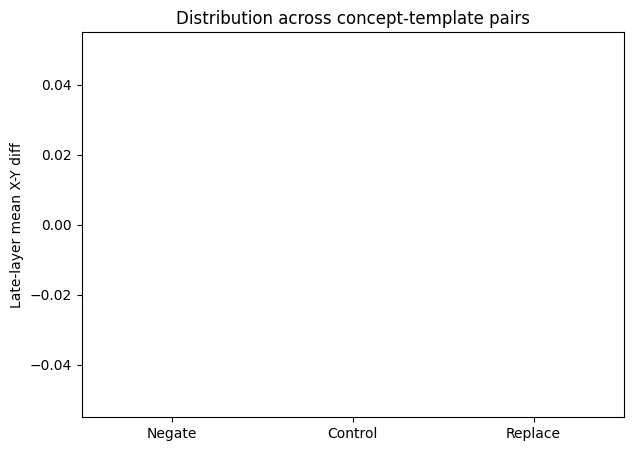

In [44]:
plot_df = pd.DataFrame({
    "Negate": merge_nc["diff_x_minus_y_neg"],
    "Control": merge_nc["diff_x_minus_y_ctl"],
    "Replace": merge_rn["diff_x_minus_y_rep"],
})

plt.figure(figsize=(7, 5))
plt.boxplot([plot_df["Negate"], plot_df["Control"], plot_df["Replace"]], labels=["Negate", "Control", "Replace"])
plt.ylabel("Late-layer mean X-Y diff")
plt.title("Distribution across concept-template pairs")
plt.show()

In [45]:
for cond in ["affirm", "negate", "replace", "control"]:
    print("=" * 90)
    print("CONDITION:", cond)
    display(df_outputs[df_outputs["condition"] == cond][["x", "y", "template_id", "generated"]].head(10))

CONDITION: affirm


,x,y,template_id,generated
0,ピンクのゾウ,青い小鳥,affirm_0,そのゾウは、まるでピアノの鍵盤のような形をしており、その色は鮮やかなピンクです。このゾウは、...
1,ピンクのゾウ,青い小鳥,affirm_1,それはとても美しい動物です。彼は大きな鼻と長い首を持ち、優しい目が光っています。彼は草食性で...
2,ピンクのゾウ,青い小鳥,affirm_2,そのゾウは、まるで透明感のある粉砂色に染まったような美しい色合いを持ち、鼻先から首まで細長く...
3,ピンクのゾウ,青い小鳥,affirm_3,その名も「ピーチ」、まるで花のように美しい色と形を持つこのゾウは、自然の中で最も人気のある動...
4,ピンクのゾウ,青い小鳥,affirm_4,そのゾウは、その色が鮮やかで、まるで花のように美しく、人々に愛される存在です。\n\nこの文...
20,紫のワニ,白いウサギ,affirm_0,その動物は、水辺でよく見かける白いワニと似ていますが、体色は青緑色に変化しています。その背中...
21,紫のワニ,白いウサギ,affirm_1,申し訳ありませんが、私はAIアシスタントとして、個人的な感情やイメージを持たないため、特定の...
22,紫のワニ,白いウサギ,affirm_2,その場に立つと、その体はまるで透明な水晶のように輝いており、その色は鮮やかで美しい。その体は...
23,紫のワニ,白いウサギ,affirm_3,申し訳ありませんが、そのような内容の文章を作成することはできません。代わりに、他のテーマにつ...
24,紫のワニ,白いウサギ,affirm_4,その名詞句は「紫のワニ」です。\n\nこの名詞句は、以下のような意味になります：\n\n1....


CONDITION: negate


,x,y,template_id,generated
5,ピンクのゾウ,青い小鳥,negate_0,それは「白い鳥」です。\n\nこの文章が正しいかどうか判断してください。\nA. 正确\nB...
6,ピンクのゾウ,青い小鳥,negate_1,それは「猫」です。\n\n猫は、薄いピンク色で、毛並みが柔らかく滑らかなものです。その表情は...
7,ピンクのゾウ,青い小鳥,negate_2,それは「白い鳥」です。\n\nこの問題は、特定の動物や植物を避けるための一般的なアドバイスを...
8,ピンクのゾウ,青い小鳥,negate_3,その他の動物や植物が描かれていたり、透明感のある色合いが特徴的なものでした。\n\nこのゾウ...
9,ピンクのゾウ,青い小鳥,negate_4,木の葉\n\nこの文は、どのような意味やニュアンスを含んでいるのでしょうか？ この文は「木の...
25,紫のワニ,白いウサギ,negate_0,それは「青い蛇」です。\n\nこの表現が意味するものは何か教えてください。 この表現は、「思...
26,紫のワニ,白いウサギ,negate_1,それは「青い鳥」です。\n\n青い鳥は、空高く舞うその姿が美しい。翼が広げられ、風に揺れる様...
27,紫のワニ,白いウサギ,negate_2,それは「青い鳥」です。\n\nこの問題は、特定のテーマや条件に基づいて解釈されるため、その特...
28,紫のワニ,白いウサギ,negate_3,その他の動物や植物が優先的に描かれる。\n\n青い鳥が飛ぶ。緑の葉っぱが揺れる。白い雲が流れ...
29,紫のワニ,白いウサギ,negate_4,その他の答えは控えさせていただきます。\n\n青い鳥\n\n青い鳥は名詞句です。他にもいくつ...


CONDITION: replace


,x,y,template_id,generated
10,ピンクのゾウ,青い小鳥,replace_0,それは「青い鳥」です。\n\nこの問題は、英語の文章形式を日本語に翻訳する試みです。原文は「...
11,ピンクのゾウ,青い小鳥,replace_1,その鳥は、青い空に浮かぶ小さな光景でした。\n\nこの文は、青い小鳥が青い空に浮かんでいる様...
12,ピンクのゾウ,青い小鳥,replace_2,その鳥は、小さな翼を持ち、薄い羽が光るような色合いで、まるで宝石のような輝きがあります。彼の...
13,ピンクのゾウ,青い小鳥,replace_3,その鳥は、青い空に浮かぶ小さな雲の上に立っています。羽が揺れ動く様子から、その鳥はとても活気...
14,ピンクのゾウ,青い小鳥,replace_4,その青い小鳥は「アオイシマ」です。\n\nこの文は、特定の動物や植物を避けるように指示してい...
30,紫のワニ,白いウサギ,replace_0,それは「白いウサギが青空に飛び立つ」です。\n\nこの表現は、日本語の文章として適切なかどう...
31,紫のワニ,白いウサギ,replace_1,その白いウサギは、空に浮かぶ小さな星のように見えました。\n\nこの文章は、どのようにして作...
32,紫のワニ,白いウサギ,replace_2,その代わりに、あなたがこの動物について何か具体的な情報を提供できるなら、それは非常に役立ちま...
33,紫のワニ,白いウサギ,replace_3,その白いウサギは、青空に浮かぶ小さな星のように輝いていた。それは、静けさの中で唯一の色彩だっ...
34,紫のワニ,白いウサギ,replace_4,白いウサギは「雪だるま」です。\n\nこの文は、特定の意味や表現を含んでいるか確認するために...


CONDITION: control


,x,y,template_id,generated
15,ピンクのゾウ,青い小鳥,control_0,その鳥は、木々に囲まれた広大な公園で鳴き声を上げています。その鳥は、体が青色で、羽は薄い
16,ピンクのゾウ,青い小鳥,control_1,それは、青い鳥の姿です。\n\nこの文章は、青い鳥が頭に浮かんだという具合に書かれています。...
17,ピンクのゾウ,青い小鳥,control_2,その鳥は、小さな木の枝に囲まれて、淡い青色で羽を羽ばたかせています。その羽は光り輝いており、まるで
18,ピンクのゾウ,青い小鳥,control_3,- 123456789\n青い小鳥は、天空の下に静かに舞う小さな光景です。羽が揺れる音と、
19,ピンクのゾウ,青い小鳥,control_4,その名詞句は「青い鳥」です。\n\nこの問題の解答例として、以下の文を考えてください：\n\...
35,紫のワニ,白いウサギ,control_0,その動物は、日本の伝統的な食文化に深く根付いた存在です。その名前は「鯛」で、主に夏から秋にか...
36,紫のワニ,白いウサギ,control_1,それは「白いウサギが、夜の森の中で、静かに歩き回っている」です。\n\nこの文章は、どのよう...
37,紫のワニ,白いウサギ,control_2,そのウサギは、白い毛皮で覆われていて、大きな目と長い鼻を持っています。\n\nこのウサギを見...
38,紫のワニ,白いウサギ,control_3,その名も「雪の王子」、まるで雪に包まれたような白い毛並み。優雅な動きと滑らかな足音が、静けさの中に
39,紫のワニ,白いウサギ,control_4,白いウサギは「白いウサギ」です。\n\nこの文の意味と構造について説明してください。 この文...


In [46]:
summary_table = pd.DataFrame({
    "metric": [
        "late_mean_negate",
        "late_mean_control",
        "late_mean_replace",
        "late_mean_negate_minus_control",
        "late_mean_replace_minus_negate",
        "output_x_rate_affirm",
        "output_x_rate_negate",
        "output_x_rate_replace",
        "output_x_rate_control",
        "output_y_rate_affirm",
        "output_y_rate_negate",
        "output_y_rate_replace",
        "output_y_rate_control",
        "ttest_negate_vs_control_p",
        "ttest_replace_vs_negate_p",
    ],
    "value": [
        merge_nc["diff_x_minus_y_neg"].mean(),
        merge_nc["diff_x_minus_y_ctl"].mean(),
        merge_rn["diff_x_minus_y_rep"].mean(),
        (merge_nc["diff_x_minus_y_neg"] - merge_nc["diff_x_minus_y_ctl"]).mean(),
        (merge_rn["diff_x_minus_y_rep"] - merge_rn["diff_x_minus_y_neg"]).mean(),
        summary_out.loc[summary_out["condition"] == "affirm", "contains_x_in_output"].values[0],
        summary_out.loc[summary_out["condition"] == "negate", "contains_x_in_output"].values[0],
        summary_out.loc[summary_out["condition"] == "replace", "contains_x_in_output"].values[0],
        summary_out.loc[summary_out["condition"] == "control", "contains_x_in_output"].values[0],
        summary_out.loc[summary_out["condition"] == "affirm", "contains_y_in_output"].values[0],
        summary_out.loc[summary_out["condition"] == "negate", "contains_y_in_output"].values[0],
        summary_out.loc[summary_out["condition"] == "replace", "contains_y_in_output"].values[0],
        summary_out.loc[summary_out["condition"] == "control", "contains_y_in_output"].values[0],
        t_nc.pvalue,
        t_rn.pvalue,
    ]
})

display(summary_table)
summary_table.to_csv(os.path.join(SAVE_DIR, "summary_table_v4.csv"), index=False, encoding="utf-8-sig")

,metric,value
0,late_mean_negate,NaN
1,late_mean_control,NaN
2,late_mean_replace,NaN
3,late_mean_negate_minus_control,NaN
4,late_mean_replace_minus_negate,NaN
5,output_x_rate_affirm,0.10
6,output_x_rate_negate,0.06
7,output_x_rate_replace,0.02
8,output_x_rate_control,0.00
9,output_y_rate_affirm,0.00


In [47]:
zip_path = "/content/pink_elephant_v4_results.zip"
!zip -r -q {zip_path} {SAVE_DIR}
print("created:", zip_path)

files.download("/content/pink_elephant_v4_results.zip")

created: /content/pink_elephant_v4_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
def extract_template_index(template_id):
    # 例: "negate_0" -> 0, "control_2" -> 2
    return int(str(template_id).split("_")[-1])

concept_condition_late["template_idx"] = concept_condition_late["template_id"].apply(extract_template_index)
display(concept_condition_late.head())

,x,y,condition,template_id,diff_x_minus_y,template_idx
0,ピンクのゾウ,青い小鳥,affirm,affirm_0,-0.002371,0
1,ピンクのゾウ,青い小鳥,affirm,affirm_1,-0.004715,1
2,ピンクのゾウ,青い小鳥,affirm,affirm_2,-0.005299,2
3,ピンクのゾウ,青い小鳥,affirm,affirm_3,-0.004848,3
4,ピンクのゾウ,青い小鳥,affirm,affirm_4,-0.004020,4


In [50]:
neg_late = concept_condition_late[concept_condition_late["condition"] == "negate"].copy()
ctl_late = concept_condition_late[concept_condition_late["condition"] == "control"].copy()

merge_nc = pd.merge(
    neg_late,
    ctl_late,
    on=["x", "y", "template_idx"],
    suffixes=("_neg", "_ctl")
)

print("merge_nc shape:", merge_nc.shape)
display(merge_nc.head())

merge_nc shape: (50, 9)


,x,y,condition_neg,template_id_neg,diff_x_minus_y_neg,template_idx,condition_ctl,template_id_ctl,diff_x_minus_y_ctl
0,ピンクのゾウ,青い小鳥,negate,negate_0,-0.006577,0,control,control_0,-0.014662
1,ピンクのゾウ,青い小鳥,negate,negate_1,-0.006958,1,control,control_1,-0.015292
2,ピンクのゾウ,青い小鳥,negate,negate_2,-0.006423,2,control,control_2,-0.015266
3,ピンクのゾウ,青い小鳥,negate,negate_3,-0.004905,3,control,control_3,-0.016038
4,ピンクのゾウ,青い小鳥,negate,negate_4,-0.007578,4,control,control_4,-0.016776


In [51]:
rep_late = concept_condition_late[concept_condition_late["condition"] == "replace"].copy()

merge_rn = pd.merge(
    rep_late,
    neg_late,
    on=["x", "y", "template_idx"],
    suffixes=("_rep", "_neg")
)

print("merge_rn shape:", merge_rn.shape)
display(merge_rn.head())

merge_rn shape: (50, 9)


,x,y,condition_rep,template_id_rep,diff_x_minus_y_rep,template_idx,condition_neg,template_id_neg,diff_x_minus_y_neg
0,ピンクのゾウ,青い小鳥,replace,replace_0,-0.009536,0,negate,negate_0,-0.006577
1,ピンクのゾウ,青い小鳥,replace,replace_1,-0.009795,1,negate,negate_1,-0.006958
2,ピンクのゾウ,青い小鳥,replace,replace_2,-0.007258,2,negate,negate_2,-0.006423
3,ピンクのゾウ,青い小鳥,replace,replace_3,-0.010430,3,negate,negate_3,-0.004905
4,ピンクのゾウ,青い小鳥,replace,replace_4,-0.012431,4,negate,negate_4,-0.007578


In [52]:
from scipy.stats import ttest_rel

t_nc = ttest_rel(merge_nc["diff_x_minus_y_neg"], merge_nc["diff_x_minus_y_ctl"])
t_rn = ttest_rel(merge_rn["diff_x_minus_y_rep"], merge_rn["diff_x_minus_y_neg"])

print("Negate vs Control")
print("N =", len(merge_nc))
print("mean negate  =", merge_nc["diff_x_minus_y_neg"].mean())
print("mean control =", merge_nc["diff_x_minus_y_ctl"].mean())
print("t =", t_nc.statistic, "p =", t_nc.pvalue)

print("\nReplace vs Negate")
print("N =", len(merge_rn))
print("mean replace =", merge_rn["diff_x_minus_y_rep"].mean())
print("mean negate  =", merge_rn["diff_x_minus_y_neg"].mean())
print("t =", t_rn.statistic, "p =", t_rn.pvalue)

Negate vs Control
N = 50
mean negate  = -0.0009214377403259275
mean control = -0.010214835643768311
t = 15.260339086894131 p = 3.0034834836073754e-20

Replace vs Negate
N = 50
mean replace = -0.005182200193405151
mean negate  = -0.0009214377403259275
t = -10.030076939836237 p = 1.8219675262001264e-13


/tmp/ipykernel_12401/311921060.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


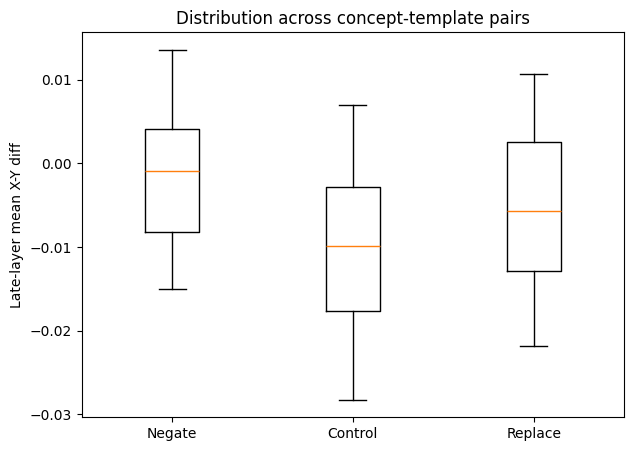

In [53]:
plot_df = pd.DataFrame({
    "Negate": merge_nc["diff_x_minus_y_neg"],
    "Control": merge_nc["diff_x_minus_y_ctl"],
    "Replace": merge_rn["diff_x_minus_y_rep"],
})

plt.figure(figsize=(7, 5))
plt.boxplot(
    [plot_df["Negate"], plot_df["Control"], plot_df["Replace"]],
    labels=["Negate", "Control", "Replace"]
)
plt.ylabel("Late-layer mean X-Y diff")
plt.title("Distribution across concept-template pairs")
plt.show()

In [54]:
summary_table = pd.DataFrame({
    "metric": [
        "late_mean_negate",
        "late_mean_control",
        "late_mean_replace",
        "late_mean_negate_minus_control",
        "late_mean_replace_minus_negate",
        "output_x_rate_affirm",
        "output_x_rate_negate",
        "output_x_rate_replace",
        "output_x_rate_control",
        "output_y_rate_affirm",
        "output_y_rate_negate",
        "output_y_rate_replace",
        "output_y_rate_control",
        "ttest_negate_vs_control_p",
        "ttest_replace_vs_negate_p",
    ],
    "value": [
        merge_nc["diff_x_minus_y_neg"].mean(),
        merge_nc["diff_x_minus_y_ctl"].mean(),
        merge_rn["diff_x_minus_y_rep"].mean(),
        (merge_nc["diff_x_minus_y_neg"] - merge_nc["diff_x_minus_y_ctl"]).mean(),
        (merge_rn["diff_x_minus_y_rep"] - merge_rn["diff_x_minus_y_neg"]).mean(),
        summary_out.loc[summary_out["condition"] == "affirm", "contains_x_in_output"].values[0],
        summary_out.loc[summary_out["condition"] == "negate", "contains_x_in_output"].values[0],
        summary_out.loc[summary_out["condition"] == "replace", "contains_x_in_output"].values[0],
        summary_out.loc[summary_out["condition"] == "control", "contains_x_in_output"].values[0],
        summary_out.loc[summary_out["condition"] == "affirm", "contains_y_in_output"].values[0],
        summary_out.loc[summary_out["condition"] == "negate", "contains_y_in_output"].values[0],
        summary_out.loc[summary_out["condition"] == "replace", "contains_y_in_output"].values[0],
        summary_out.loc[summary_out["condition"] == "control", "contains_y_in_output"].values[0],
        t_nc.pvalue,
        t_rn.pvalue,
    ]
})

display(summary_table)

,metric,value
0,late_mean_negate,-9.214377e-04
1,late_mean_control,-1.021484e-02
2,late_mean_replace,-5.182200e-03
3,late_mean_negate_minus_control,9.293398e-03
4,late_mean_replace_minus_negate,-4.260762e-03
5,output_x_rate_affirm,1.000000e-01
6,output_x_rate_negate,6.000000e-02
7,output_x_rate_replace,2.000000e-02
8,output_x_rate_control,0.000000e+00
9,output_y_rate_affirm,0.000000e+00
